 # TP-01 : Analyse des prix alimentaires au Burkina Faso (WFP)
 **Source des données :** WFP / Humanitarian Data Exchange  
 **Période couverte :** 1992 – 2025  

 ## 📋 Contexte
Le Programme Alimentaire Mondial (WFP) collecte depuis 1992 les prix 
des denrées alimentaires sur différents marchés du Burkina Faso. 
Ces données sont cruciales pour comprendre la sécurité alimentaire, 
l'inflation et la vulnérabilité des populations.

## 🎯 Objectifs
- Importer et explorer un large dataset CSV (~70 000 observations)
- Nettoyer et préparer les données pour l'analyse
- Calculer des statistiques agrégées avec NumPy et Pandas
- Créer des visualisations temporelles, géographiques et statistiques
- Identifier des tendances et anomalies sur les marchés alimentaires

## Partie A : Import et exploration initiale
### Import du dataset
Importation des bibliothèques nécessaires et chargement du fichier CSV.  
On vérifie ensuite la structure générale du dataset avec `.info()`, 
`.shape()` et `.dtypes` et les doublons. 

In [2]:
# Importation des bibliothèques nécessaires à notre analyse 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Chargement et affichage du dataset
df = pd.read_csv(r"C:\Users\Diall\Downloads\TP_python\Datasets\wfp_food_prices_bfa.csv")
display(df.head(10))
display(df.tail(10))

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,1992-01-15,BOUCLE DU MOUHOUN,SOUROU,Tougan,141,13.07,-3.07,cereals and tubers,Millet,73,KG,actual,Retail,XOF,53.00,0.13
1,1992-01-15,CASCADES,COMOÉ,Banfora,129,10.63,-4.77,cereals and tubers,Millet,73,KG,actual,Retail,XOF,82.00,0.20
2,1992-01-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,90.00,0.21
3,1992-01-15,CENTRE-EST,BOULGOU,Tenkodogo,140,11.78,-0.37,cereals and tubers,Millet,73,KG,actual,Retail,XOF,77.00,0.18
4,1992-01-15,CENTRE-NORD,BAM,Kongoussi,137,13.33,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,55.50,0.13
5,1992-01-15,CENTRE-OUEST,BOULKIEMDÉ,Koudougou,138,12.25,-2.37,cereals and tubers,Millet,73,KG,actual,Retail,XOF,69.00,0.16
6,1992-01-15,EST,GOURMA,Fada N'Gourma,134,12.06,0.36,cereals and tubers,Millet,73,KG,actual,Retail,XOF,70.25,0.17
7,1992-01-15,SAHEL,OUDALAN,Gorom Gorom,135,14.44,-0.24,cereals and tubers,Millet,73,KG,actual,Retail,XOF,75.75,0.18
8,1992-01-15,SAHEL,SOUM,Djibo,132,14.10,-1.63,cereals and tubers,Millet,73,KG,actual,Retail,XOF,57.67,0.14
9,1992-01-15,SAHEL,SÉNO,Dori,133,14.03,-0.03,cereals and tubers,Millet,73,KG,actual,Retail,XOF,73.00,0.17


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
57385,2026-04-15,SUD-OUEST,NOUMBIEL,Batié,3362,9.88,-2.92,pulses and nuts,Beans (niebe),120,KG,actual,Retail,XOF,506.0,0.91
57386,2026-04-15,SUD-OUEST,NOUMBIEL,Batié,3362,9.88,-2.92,pulses and nuts,Groundnuts (shelled),119,KG,actual,Retail,XOF,770.0,1.38
57387,2026-04-15,SUD-OUEST,NOUMBIEL,Batié,3362,9.88,-2.92,pulses and nuts,Groundnuts (unshelled),118,KG,actual,Retail,XOF,400.0,0.72
57388,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,cereals and tubers,Maize (white),67,KG,actual,Retail,XOF,219.0,0.39
57389,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,cereals and tubers,Millet,73,KG,actual,Retail,XOF,340.0,0.61
57390,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,cereals and tubers,Rice (imported),64,KG,actual,Retail,XOF,518.0,0.93
57391,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,cereals and tubers,Rice (local),71,KG,actual,Retail,XOF,417.0,0.75
57392,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,cereals and tubers,Sorghum (white),135,KG,actual,Retail,XOF,332.0,0.60
57393,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,pulses and nuts,Beans (niebe),120,KG,actual,Retail,XOF,472.0,0.85
57394,2026-04-15,SUD-OUEST,PONI,Gaoua,3373,10.33,-3.18,pulses and nuts,Groundnuts (unshelled),118,KG,actual,Retail,XOF,556.0,1.00


In [4]:
# inspection generale du dataset
df.info()
print(df.shape)
print(df.describe())
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 57395 entries, 0 to 57394
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          57395 non-null  str    
 1   admin1        57395 non-null  str    
 2   admin2        57395 non-null  str    
 3   market        57395 non-null  str    
 4   market_id     57395 non-null  int64  
 5   latitude      57395 non-null  float64
 6   longitude     57395 non-null  float64
 7   category      57395 non-null  str    
 8   commodity     57395 non-null  str    
 9   commodity_id  57395 non-null  int64  
 10  unit          57395 non-null  str    
 11  priceflag     57395 non-null  str    
 12  pricetype     57395 non-null  str    
 13  currency      57395 non-null  str    
 14  price         57395 non-null  float64
 15  usdprice      57395 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 7.0 MB
(57395, 16)
          market_id      latitude     longitude  commodit

In [5]:
# Verification des doublons et valeurs manquantes
print(df.isna().sum())
print(df.duplicated().sum()) 

date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64
0


###  Exploration des données
Analyse des valeurs uniques pour les colonnes clés :
- `price` : statistiques descriptives
- `commodity` : produits disponibles
- `admin1` : régions couvertes
- `market` : marchés recensés

In [6]:
#  les statistiques descriptives pour la colonne  price(Prix)
stat_desc_price = df["price"].describe()
print(stat_desc_price)

count    57395.000000
mean      2063.720678
std       6884.799697
min         33.000000
25%        179.210000
50%        280.000000
75%        417.000000
max      45000.000000
Name: price, dtype: float64


In [7]:
# Identification des produits uniques dans la colonne  commodity(Cereales)
prod = df["commodity"].unique()
sum_by_prod = df["commodity"].value_counts()
print(prod)
print(sum_by_prod)

<StringArray>
[                'Millet',                  'Maize',                   'Rice',
                'Sorghum',          'Beans (niebe)',          'Maize (white)',
        'Sorghum (white)',        'Rice (imported)',        'Sorghum (local)',
           'Rice (local)', 'Groundnuts (unshelled)',   'Groundnuts (shelled)']
Length: 12, dtype: str
commodity
Millet                    12958
Sorghum (white)            9579
Maize (white)              8784
Beans (niebe)              8191
Groundnuts (unshelled)     5176
Rice (imported)            4357
Rice (local)               4219
Groundnuts (shelled)       2558
Sorghum (local)            1417
Maize                        63
Sorghum                      63
Rice                         30
Name: count, dtype: int64


In [8]:

# Identification des regions uniques dans la colonne  admin1(Region)
reg = df["admin1"].unique()
sum_by_reg = df["admin1"].value_counts()
print(reg)
print(sum_by_reg)

<StringArray>
['BOUCLE DU MOUHOUN',          'CASCADES',            'CENTRE',
        'CENTRE-EST',       'CENTRE-NORD',      'CENTRE-OUEST',
               'EST',             'SAHEL',         'SUD-OUEST',
              'NORD',   'PLATEAU-CENTRAL',     'HAUTS-BASSINS',
        'CENTRE-SUD']
Length: 13, dtype: str
admin1
BOUCLE DU MOUHOUN    8771
EST                  6086
SAHEL                5978
HAUTS-BASSINS        4987
SUD-OUEST            4893
CENTRE-EST           4654
CENTRE-OUEST         4002
CENTRE-NORD          3778
CENTRE-SUD           3382
NORD                 3244
PLATEAU-CENTRAL      2839
CENTRE               2683
CASCADES             2098
Name: count, dtype: int64


In [9]:
# Identification des marches uniques dans la colonne  market(Marche)
mark = df["market"].unique()
sum_by_mark = df["market"].value_counts()
print(mark)
print(sum_by_mark)

<StringArray>
[                 'Tougan',                 'Banfora',
 'Ouagadougo (Sankaryare)',               'Tenkodogo',
               'Kongoussi',               'Koudougou',
           'Fada N'Gourma',             'Gorom Gorom',
                   'Djibo',                    'Dori',
               'Diebougou',         'Kantchari (CBM)',
                  'Gourcy',                  'Bousse',
                   'Nouna',                'Dedougou',
           'Namouno (CBM)',          'Bobo Dioulasso',
              'Ouahigouya',                  'Boromo',
                    'Fara',                 'Solenzo',
                'Djibasso',                  'Gassan',
                    'Toma',                   'Douna',
                'Gounghin',                   'Zabré',
                'Ouargaye',                 'Koupela',
                  'Boulsa',                   'Yalgo',
                     'Réo',                    'Tita',
                  'Sapouy',              'Kombissir

### Transformation des dates
Conversion de la colonne `date` en type `datetime` et extraction 
de l'année, du mois et du jour dans des colonnes séparées.  
Calcul de la durée totale couverte par le dataset.

In [10]:
# Transformation des dates
df["date"] = pd.to_datetime(df["date"])
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour"] = df["date"].dt.day



In [11]:
# Identification de la premiere et la derniere annee
annee_minimale = df["annee"].min()
annee_maximal = df["annee"].max()

# Nombre d'annee du dataset
nombre_annee = annee_maximal - annee_minimale + 1

print(annee_minimale)
print(annee_maximal)
print(nombre_annee)

1992
2026
35


## Partie B : Nettoyage et préparation des données
### Gestion des valeurs manquantes
Détection et traitement des valeurs manquantes par colonne.  
Calcul du pourcentage de valeurs manquantes et suppression 
des lignes où le prix est absent.

In [12]:
# le nombre de valeurs manquantes par colonne
df.isna().sum()

#  le pourcentage de valeurs manquantes pour chaque colonne
pourcentage_valeurs_manquante = df.isna().sum() / len(df) * 100
print(pourcentage_valeurs_manquante)

#  Suppressions les lignes où le prix ( price ) est manquant
df.dropna(subset = ["price"], inplace=True )

date            0.0
admin1          0.0
admin2          0.0
market          0.0
market_id       0.0
latitude        0.0
longitude       0.0
category        0.0
commodity       0.0
commodity_id    0.0
unit            0.0
priceflag       0.0
pricetype       0.0
currency        0.0
price           0.0
usdprice        0.0
annee           0.0
mois            0.0
jour            0.0
dtype: float64


### Détection des anomalies
Identification des prix négatifs et des valeurs aberrantes 
via un boxplot la règle des 3 écarts-types.  

> **Décision :** Les outliers sont conservés car les prix élevés 
> observés correspondent aux grandes villes, ce qui est 
> économiquement cohérent.

Empty DataFrame
Columns: [date, admin1, admin2, market, market_id, latitude, longitude, category, commodity, commodity_id, unit, priceflag, pricetype, currency, price, usdprice, annee, mois, jour]
Index: []


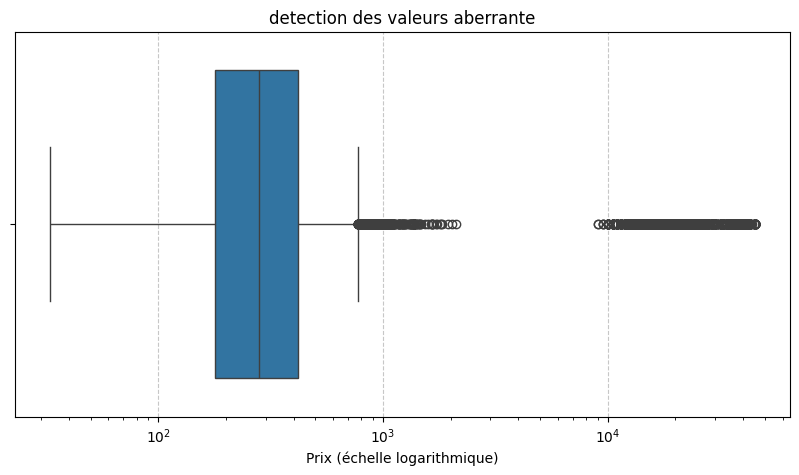

In [ ]:
# Identification des prix négatifs (s'il y en a) et suppression
prix_negatif = df[df["price"] < 0]
print(prix_negatif)

# Créeation d'un boxplot des prix pour identifier les valeurs aberrantes extrêmes
plt.figure(figsize= (10, 5))
sns.boxplot(x= "price", data= df)
plt.xlabel("Prix (échelle logarithmique)")
plt.title("detection des valeurs aberrante")
plt.xscale('log')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig("figures/Boxplot_identification_outliers.png", dpi=300)
plt.show()

#  Calculons les prix au-delà de 3 écarts-types de la moyenne et affichons-les
moyenne_bas = df["price"].mean() - (3 * df["price"].std())
moyenne_haut = df["price"].mean() + (3 * df["price"].std())
outliers = df[(df["price"] < moyenne_bas) | (df["price"] > moyenne_haut)]


In [14]:
# Affichage et decision sur les outliers
display(outliers)
print(len(outliers))
print(len(df))

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,annee,mois,jour
2712,2006-01-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,24000.0,57.08,2006,1,15
2737,2006-01-15,SAHEL,SÉNO,Dori,133,14.03,-0.03,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,26000.0,61.84,2006,1,15
2752,2006-02-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,24000.0,57.08,2006,2,15
2781,2006-02-15,SAHEL,SÉNO,Dori,133,14.03,-0.03,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,26000.0,61.84,2006,2,15
2796,2006-03-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,24000.0,57.08,2006,3,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39791,2022-06-15,HAUTS-BASSINS,HOUET,Bobo Dioulasso,2569,11.18,-4.28,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,40000.0,64.34,2022,6,15
39792,2022-06-15,HAUTS-BASSINS,HOUET,Bobo Dioulasso,2569,11.18,-4.28,cereals and tubers,Sorghum (local),511,100 KG,actual,Wholesale,XOF,27000.0,43.43,2022,6,15
39896,2022-06-15,SAHEL,SÉNO,Dori,133,14.03,-0.03,cereals and tubers,Millet,73,100 KG,actual,Wholesale,XOF,38000.0,61.12,2022,6,15
39898,2022-06-15,SAHEL,SÉNO,Dori,133,14.03,-0.03,cereals and tubers,Rice (imported),64,100 KG,actual,Wholesale,XOF,40000.0,64.34,2022,6,15


1647
57395


### Filtrage des céréales principales
Création d'un DataFrame filtré `cereales_df` contenant uniquement 
les 4 céréales d'intérêt :
- 🌾 Mil (Millet)
- 🌽 Maïs (Maize)
- 🍚 Riz (Rice)
- 🌿 Sorgho (Sorghum)

In [15]:
# Filtrage des cereales principales
cereales_df = df[df["commodity"].isin(["Millet", "Maize", "Rice", "Sorghum"])]
display(cereales_df)
print(cereales_df["commodity"].unique())
print(len(cereales_df))

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,annee,mois,jour
0,1992-01-15,BOUCLE DU MOUHOUN,SOUROU,Tougan,141,13.07,-3.07,cereals and tubers,Millet,73,KG,actual,Retail,XOF,53.0,0.13,1992,1,15
1,1992-01-15,CASCADES,COMOÉ,Banfora,129,10.63,-4.77,cereals and tubers,Millet,73,KG,actual,Retail,XOF,82.0,0.20,1992,1,15
2,1992-01-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,90.0,0.21,1992,1,15
3,1992-01-15,CENTRE-EST,BOULGOU,Tenkodogo,140,11.78,-0.37,cereals and tubers,Millet,73,KG,actual,Retail,XOF,77.0,0.18,1992,1,15
4,1992-01-15,CENTRE-NORD,BAM,Kongoussi,137,13.33,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,55.5,0.13,1992,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57361,2026-04-15,SUD-OUEST,BOUGOURIBA,Diebougou,131,10.97,-3.25,cereals and tubers,Millet,73,KG,actual,Retail,XOF,303.0,0.54,2026,4,15
57368,2026-04-15,SUD-OUEST,IOBA,Dano,3366,11.15,-3.06,cereals and tubers,Millet,73,KG,actual,Retail,XOF,198.0,0.36,2026,4,15
57375,2026-04-15,SUD-OUEST,IOBA,Hamélé,3378,11.01,-2.75,cereals and tubers,Millet,73,KG,actual,Retail,XOF,217.0,0.39,2026,4,15
57383,2026-04-15,SUD-OUEST,NOUMBIEL,Batié,3362,9.88,-2.92,cereals and tubers,Millet,73,KG,actual,Retail,XOF,367.0,0.66,2026,4,15


<StringArray>
['Millet', 'Maize', 'Rice', 'Sorghum']
Length: 4, dtype: str
13114


## Partie C : Analyse avec numpy
### Statistiques par produit
Calcul des statistiques descriptives (moyenne, médiane, écart-type, 
min, max) pour chaque céréale sur toute la période 1992–2025.

In [16]:
#  Statistiques par produit
statistique_par_produit =  cereales_df.groupby("commodity")["price"].agg(["mean", "median", "std", "max", "min"])
statistique_par_produit.columns = ["Prix Moyen", "Prix Médian", 
                                    "Écart-type", "Prix Maximum", 
                                    "Prix Minimum"]
display(statistique_par_produit)

,Prix Moyen,Prix Médian,Écart-type,Prix Maximum,Prix Minimum
commodity,,,,,
Maize,120.039206,120.0,23.499672,188.75,70.00
Millet,2232.637937,218.0,5896.925829,38000.00,33.00
Rice,322.539000,250.0,116.503500,545.00,227.50
Sorghum,125.357460,122.5,27.529165,195.00,76.67


### Analyse temporelle du Mil
- Prix moyen du mil par année
- Identification de l'année la plus chère et la moins chère
- Calcul du taux de croissance annuel moyen (TCAM)

In [17]:
# Analyse temporelle du mil (le prix moyen du mil par année, max, min)
millet_df = cereales_df[cereales_df["commodity"] == "Millet"]
display(millet_df)
prix_moyen_mil_par_an = millet_df.groupby("annee")["price"].mean()
print(prix_moyen_mil_par_an)
annee_max_vente_mil = print(prix_moyen_mil_par_an.idxmax())
annee_min_vente_mil = print(prix_moyen_mil_par_an.idxmin())



,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,annee,mois,jour
0,1992-01-15,BOUCLE DU MOUHOUN,SOUROU,Tougan,141,13.07,-3.07,cereals and tubers,Millet,73,KG,actual,Retail,XOF,53.0,0.13,1992,1,15
1,1992-01-15,CASCADES,COMOÉ,Banfora,129,10.63,-4.77,cereals and tubers,Millet,73,KG,actual,Retail,XOF,82.0,0.20,1992,1,15
2,1992-01-15,CENTRE,KADIOGO,Ouagadougo (Sankaryare),139,12.36,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,90.0,0.21,1992,1,15
3,1992-01-15,CENTRE-EST,BOULGOU,Tenkodogo,140,11.78,-0.37,cereals and tubers,Millet,73,KG,actual,Retail,XOF,77.0,0.18,1992,1,15
4,1992-01-15,CENTRE-NORD,BAM,Kongoussi,137,13.33,-1.53,cereals and tubers,Millet,73,KG,actual,Retail,XOF,55.5,0.13,1992,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57361,2026-04-15,SUD-OUEST,BOUGOURIBA,Diebougou,131,10.97,-3.25,cereals and tubers,Millet,73,KG,actual,Retail,XOF,303.0,0.54,2026,4,15
57368,2026-04-15,SUD-OUEST,IOBA,Dano,3366,11.15,-3.06,cereals and tubers,Millet,73,KG,actual,Retail,XOF,198.0,0.36,2026,4,15
57375,2026-04-15,SUD-OUEST,IOBA,Hamélé,3378,11.01,-2.75,cereals and tubers,Millet,73,KG,actual,Retail,XOF,217.0,0.39,2026,4,15
57383,2026-04-15,SUD-OUEST,NOUMBIEL,Batié,3362,9.88,-2.92,cereals and tubers,Millet,73,KG,actual,Retail,XOF,367.0,0.66,2026,4,15


annee
1992      76.542955
1993      67.578258
1994      69.276538
1995      89.420551
1996     132.450078
1997     124.767045
1998     158.442121
1999     118.106894
2000      98.780227
2001     151.204545
2002     162.284851
2003     126.026736
2004     112.002847
2005     186.354512
2006    1852.376957
2007    1757.839222
2008    5324.557917
2009    5577.212834
2010    5865.853269
2011    5688.666985
2012    8869.988798
2013    7331.858053
2014    7179.462984
2015    2312.855050
2016    2234.827374
2017    2581.346247
2018    2695.362319
2019    2101.210275
2020    2341.513253
2021    2579.041766
2022    2163.935279
2023     320.289073
2024     355.847361
2025     354.844852
2026     293.059072
Name: price, dtype: float64
2012
1993


### Analyse géographique
Comparaison des prix moyens par région pour chaque céréale.  
Identification des régions extrêmes (prix le plus élevé / le plus bas)  
et création d'un tableau croisé région × céréale.

In [18]:
# Analyse géographique
prix_moyen_cereale_par_region = cereales_df.groupby("admin1")["price"].mean()
print(prix_moyen_cereale_par_region)
# Région ou le mil est le plus eleve
region_prix_mil_max = (
    cereales_df[cereales_df["commodity"] == "Millet"]
    .groupby("admin1")["price"]
    .mean()
    .idxmax()
)
# Région où le riz est le plus bas

region_prix_riz_min = (
    cereales_df[cereales_df["commodity"] == "Rice"]
    .groupby("admin1")["price"]
    .mean()
    .idxmin()
)

print(f"Région où le Mil est le plus cher : {region_prix_mil_max}")
print(f"Région où le Riz est le moins cher : {region_prix_riz_min}")

# creation du Tableau recapitilatif

table_recapulative = cereales_df.pivot_table(index= "admin1", columns= "commodity", values= "price", aggfunc= "mean", fill_value= 0)
display(table_recapulative)


admin1
BOUCLE DU MOUHOUN    3462.658540
CASCADES              218.542950
CENTRE               5053.370619
CENTRE-EST           3058.734821
CENTRE-NORD          3375.146439
CENTRE-OUEST          207.065608
CENTRE-SUD            263.551852
EST                  2241.256673
HAUTS-BASSINS        3885.702500
NORD                  242.082525
PLATEAU-CENTRAL       224.508137
SAHEL                2422.071523
SUD-OUEST             233.715226
Name: price, dtype: float64
Région où le Mil est le plus cher : CENTRE
Région où le Riz est le moins cher : EST


commodity,Maize,Millet,Rice,Sorghum
admin1,,,,
BOUCLE DU MOUHOUN,0.000000,3462.658540,0.000,0.00000
CASCADES,0.000000,218.542950,0.000,0.00000
CENTRE,0.000000,5053.370619,0.000,0.00000
CENTRE-EST,0.000000,3058.734821,0.000,0.00000
CENTRE-NORD,0.000000,3375.146439,0.000,0.00000
CENTRE-OUEST,0.000000,207.065608,0.000,0.00000
CENTRE-SUD,0.000000,263.551852,0.000,0.00000
EST,120.039206,2470.909809,322.539,125.35746
HAUTS-BASSINS,0.000000,3885.702500,0.000,0.00000


### Analyse saisonnière
Regroupement des données par mois (indépendamment de l'année)  
pour identifier les périodes de **soudure** (prix élevés)  
et les périodes **post-récolte** (prix bas).

In [19]:
# analyse saisonnière
prix_mensuel_mil = millet_df.groupby("mois")["price"].mean()
print(prix_mensuel_mil)
mois_prix_eleve = millet_df.groupby("mois")["price"].mean().idxmax()
print(mois_prix_eleve)
mois_prix_bas = millet_df.groupby("mois")["price"].mean().idxmin()
print(mois_prix_bas)



mois
1     2112.830750
2     2109.035115
3     2169.590329
4     2269.008517
5     2392.386564
6     2439.365690
7     2213.311419
8     2320.196181
9     2296.296664
10    2243.132958
11    2147.073043
12    2093.153136
Name: price, dtype: float64
6
12


## Partie D : Visualisations avec Matplotlib et Seaborn
### Évolution temporelle du prix du Mil
Graphique en ligne de l'évolution du prix moyen du mil de 1992 à 2025,  
avec une ligne de tendance (régression linéaire) pour visualiser  
la hausse générale sur la période.

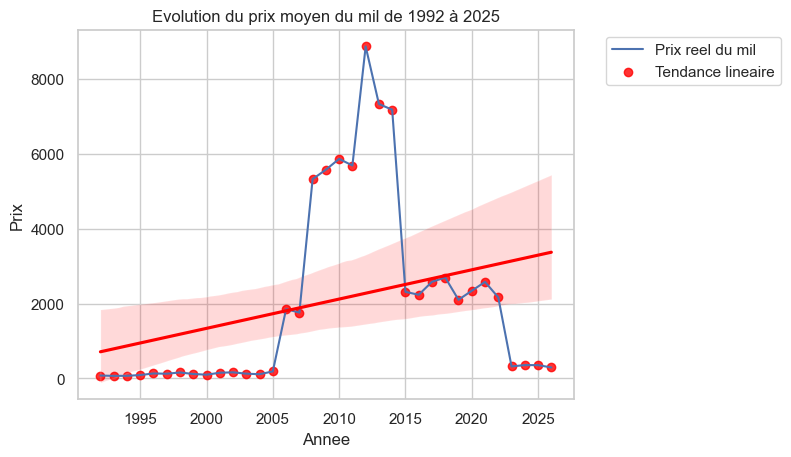

In [28]:
#  Evolution temporelle du prix du mil
sns.set_theme(style= "whitegrid")
sns.lineplot(x = prix_moyen_mil_par_an.index, y= prix_moyen_mil_par_an.values, label= "Prix reel du mil" )
sns.regplot(x = prix_moyen_mil_par_an.index, y= prix_moyen_mil_par_an.values, color= "red", label= "Tendance lineaire")
plt.xlabel("Annee")
plt.ylabel("Prix")
plt.legend( bbox_to_anchor = (1.05,1), loc= "upper left" )
plt.title("Evolution du prix moyen du mil de 1992 à 2025")
plt.savefig("figures/Evolution_prix_mil.png", dpi=300 )
plt.show()


### Comparaison des 4 céréales
Subplots 2×2 montrant l'évolution du prix de chaque céréale  
sur la même période, avec des couleurs distinctes pour chacune.

In [21]:
#  le prix moyen du mais, riz et sorgho par ans ['Millet', 'Maize', 'Rice', 'Sorghum']
prix_moyen_mais_par_an = cereales_df[cereales_df["commodity"] == "Maize"].groupby("annee")["price"].mean()
prix_moyen_riz_par_an = cereales_df[cereales_df["commodity"] == "Rice"].groupby("annee")["price"].mean()
prix_moyen_sorgho_par_an = cereales_df[cereales_df["commodity"] == "Sorghum"].groupby("annee")["price"].mean()
display(prix_moyen_mais_par_an)
display(prix_moyen_riz_par_an)
display(prix_moyen_sorgho_par_an)


annee
2002     92.500000
2003    106.528333
2005    143.273333
2006    132.734000
2009    127.188750
2010     98.363636
2011    122.424545
2012    135.000000
Name: price, dtype: float64

annee
2002    240.000000
2003    237.151818
2005    441.596667
2006    257.668000
Name: price, dtype: float64

annee
2002     82.915000
2003    102.945000
2005    150.830833
2006    140.120000
2009    123.312500
2010    112.235455
2011    132.699091
2012    152.500000
Name: price, dtype: float64

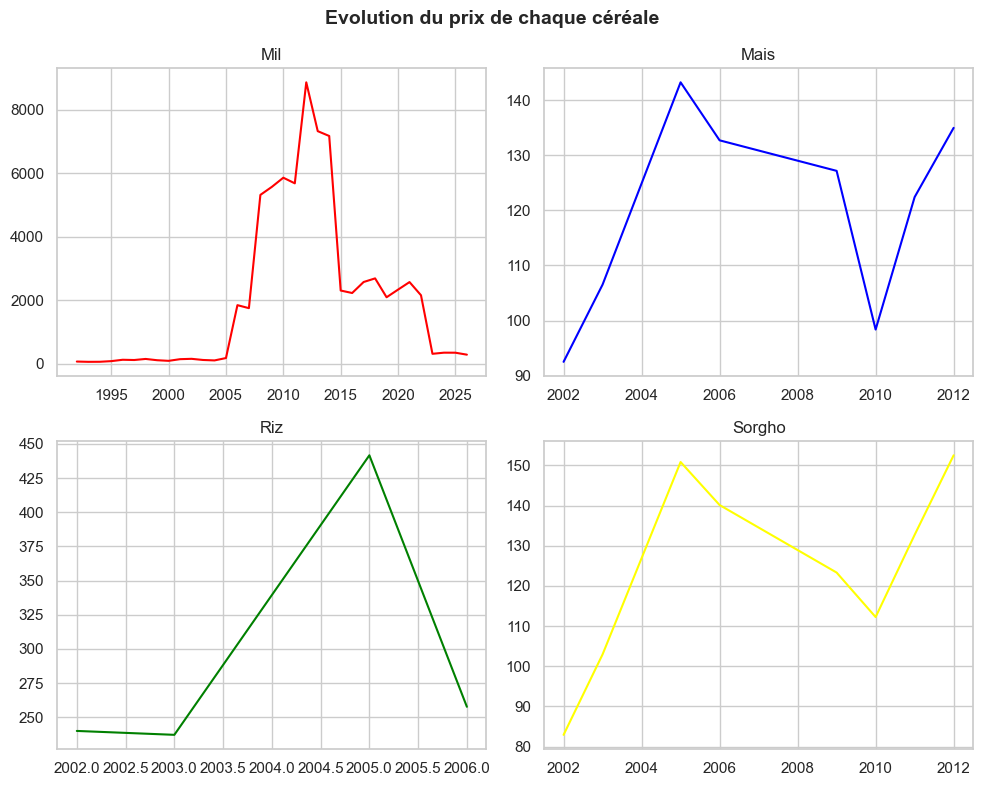

In [29]:
 # Comparaison des 4 cereales (subplots 2x2) montrant l'évolution du prix de chaque céréale
fig, axe = plt.subplots(2,2, figsize=(10, 8))
axe[0,0].plot(prix_moyen_mil_par_an.index, prix_moyen_mil_par_an.values, color = "red")
axe[0,1].plot(prix_moyen_mais_par_an.index, prix_moyen_mais_par_an.values, color = "blue")
axe[1,0].plot(prix_moyen_riz_par_an.index, prix_moyen_riz_par_an.values, color = "green")
axe[1,1].plot(prix_moyen_sorgho_par_an.index, prix_moyen_sorgho_par_an.values, color = "yellow")
axe[0,0].set_title("Mil")
axe[0,1].set_title("Mais")
axe[1,0].set_title("Riz")
axe[1,1].set_title("Sorgho")
plt.suptitle("Evolution du prix de chaque céréale",  fontsize=14,
    fontweight="bold")
plt.tight_layout()
plt.savefig("figures/Evolution_prix_cereales.png", dpi = 300 )
plt.show()

### Analyse des distributions
- Histogramme + courbe KDE du prix du mil
- Boxplot comparatif des 4 céréales
- Violinplot pour une visualisation enrichie des distributions

> **Note :** Échelle logarithmique utilisée pour mieux visualiser  
> la distribution en présence de valeurs extrêmes.

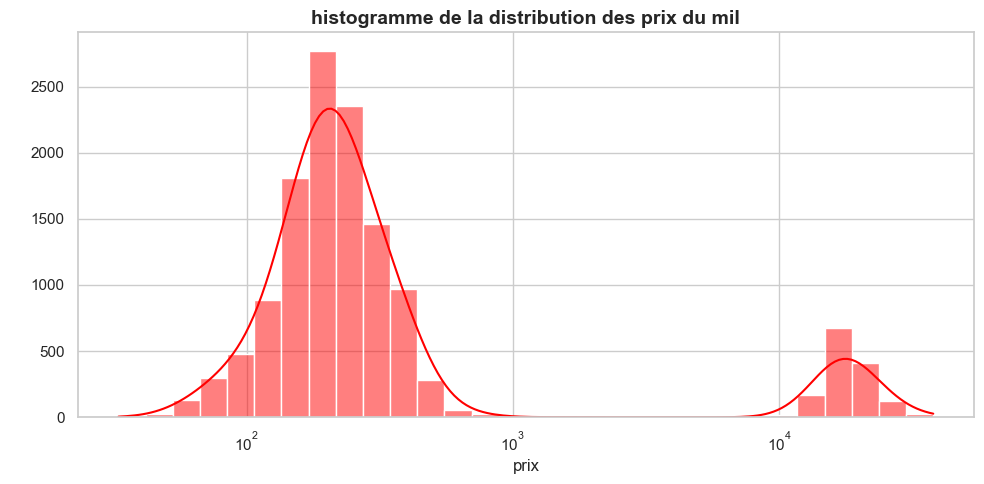

In [30]:
# Analyse des distributions
plt.figure(figsize= (10, 5))
sns.histplot(data= millet_df, x=millet_df.price, kde=True, color="red", bins=30, log_scale= True)
plt.xlabel("prix")
plt.ylabel(" ")
plt.title("histogramme de la distribution des prix du mil",  fontsize=14,
    fontweight="bold")
plt.tight_layout()
plt.savefig("figures/histogramme_distribution_prix_mil.png", dpi = 300)
plt.show()


C:\Users\Diall\AppData\Local\Temp\ipykernel_10924\1099620923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "commodity", y = "price", data = cereales_df, log_scale= True, palette="Set1")


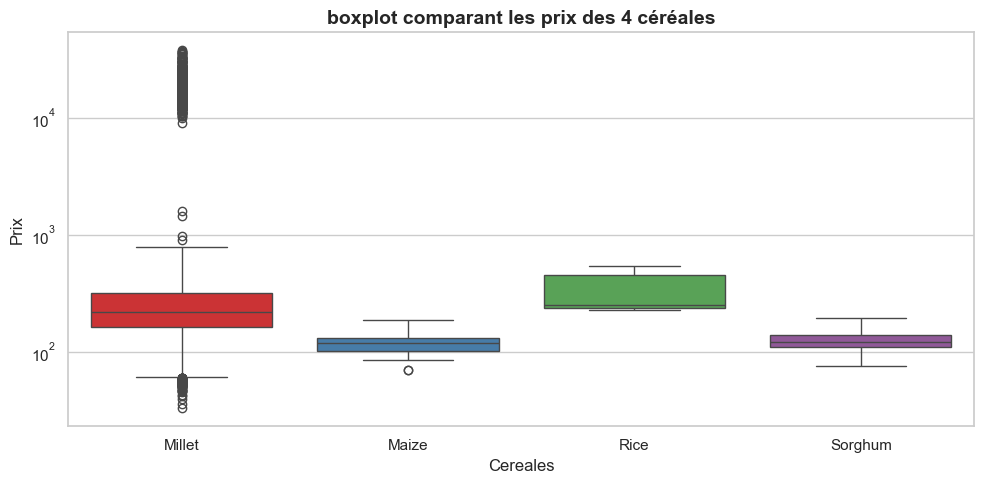

In [31]:
# boxplot comparant les prix des 4 céréales
plt.figure(figsize= (10, 5))
sns.boxplot(x = "commodity", y = "price", data = cereales_df, log_scale= True, palette="Set1")
plt.xlabel("Cereales")
plt.ylabel("Prix")
plt.title("boxplot comparant les prix des 4 céréales",  fontsize=14,fontweight="bold" )
plt.tight_layout()
plt.savefig("figures/boxplot_comparaison_prix_cereales.png", dpi= 300)
plt.show()


C:\Users\Diall\AppData\Local\Temp\ipykernel_10924\2624681059.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cereales_df, x="commodity", y="price", palette="Set1", log_scale= True)


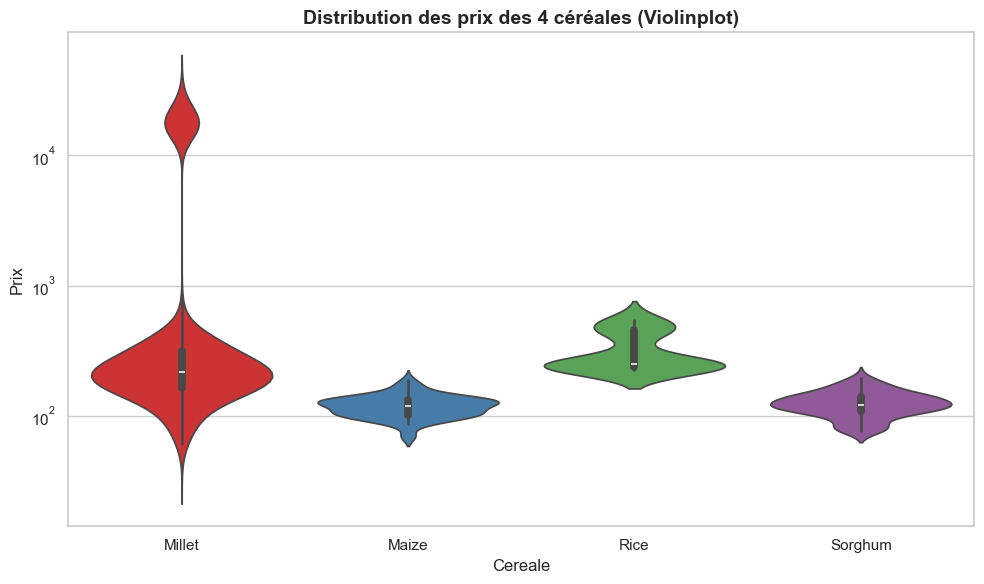

In [32]:
# Création du violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=cereales_df, x="commodity", y="price", palette="Set1", log_scale= True)
plt.title(
    "Distribution des prix des 4 céréales (Violinplot)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Cereale", fontsize=12)
plt.ylabel("Prix", fontsize=12)
plt.tight_layout()
plt.savefig("figures/Distribution_prix_cereales_violin.png", dpi=300)

plt.show()

### Analyse géographique visuelle
Barplot horizontal des prix moyens du mil par région,  
trié par ordre croissant avec les valeurs affichées sur les barres.

C:\Users\Diall\AppData\Local\Temp\ipykernel_10924\2452751845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= millet_df, x= "price", y= "admin1", order= ordre_regions, palette= "Blues")


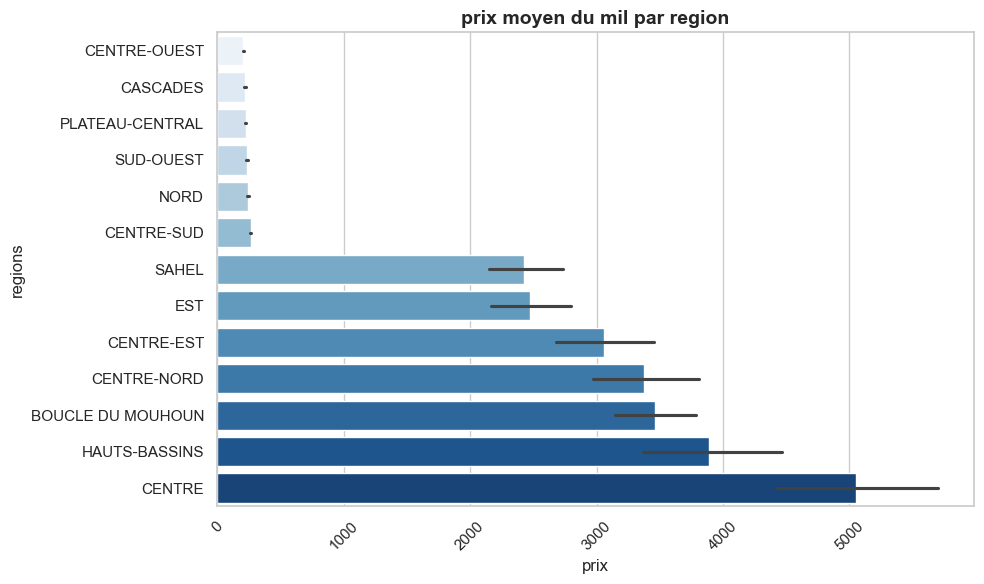

In [33]:
# barplot horizontal montrant le prix moyen du mil par région
ordre_regions = millet_df.groupby('admin1')['price'].mean().sort_values(ascending= True).index
plt.figure(figsize= (10, 6))
sns.barplot(data= millet_df, x= "price", y= "admin1", order= ordre_regions, palette= "Blues")
plt.xlabel("prix")
plt.ylabel("regions")

plt.title("prix moyen du mil par region",  fontsize=14,
    fontweight="bold")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("figures/prix_mil_par_region.png", dpi=300)
plt.show()

### Heatmap de corrélation
Matrice de corrélation entre les prix des 4 céréales.

> **Insight clé :**  
> - 🔴 Maïs–Sorgho : forte corrélation (mêmes conditions climatiques)  
> - 🔵 Mil–Riz : corrélation négative (effet de substitution)  
> - Le Riz suit la tendance générale mais avec une corrélation plus faible  
> (influence des marchés internationaux)

commodity,Maize,Millet,Rice,Sorghum
commodity,,,,
Maize,1.000000,0.203382,0.755256,0.935871
Millet,0.203382,1.000000,-0.222930,0.409807
Rice,0.755256,-0.222930,1.000000,0.722746
Sorghum,0.935871,0.409807,0.722746,1.000000


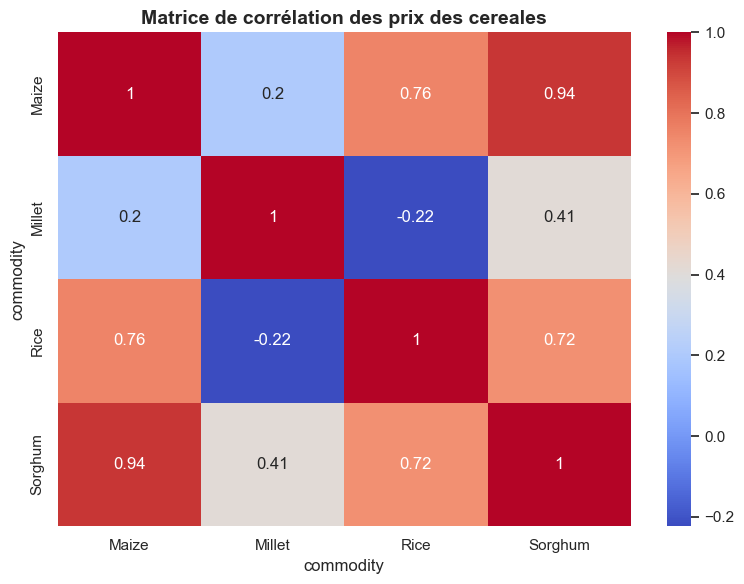

In [34]:
# DataFrame pivot avec les prix moyens annuels des 4 céréale
prix_moyens_par_an_cereales = cereales_df.pivot_table(index= "annee", columns= "commodity", values= "price", aggfunc= "mean")

# matrice de corrélation entre les prix des céréales
matrice_corr = prix_moyens_par_an_cereales.corr()
display(matrice_corr)

#heatmap de cette matrice
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr,  annot=True, cmap= "coolwarm")
plt.title("Matrice de corrélation des prix des cereales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/heatmap_correlation_cereales.png", dpi=300)
plt.show()



Le maïs et le sorgho ont des prix qui bougent pratiquement ensemble. Quand l'un augmente, l'autre augmente aussi.
Le riz suit à peu près la même tendance, mais un peu moins.

Le mil, lui, est différent. Il ne suit pas vraiment les autres céréales. Et il a un comportement particulier avec le riz : quand le riz est cher, le millet a tendance à être moins cher, et inversement. Comme si les gens choisissaient l'un ou l'autre en fonction du prix.


---
## ✅ Conclusion

### Principales découvertes
1. **Hausse générale** des prix sur 33 ans reflétant l'inflation
2. **Disparités géographiques** : prix plus élevés dans les grandes villes
3. **Saisonnalité marquée** : pics en période de soudure
4. **Forte corrélation Maïs–Sorgho** : cultures soumises aux mêmes aléas climatiques
5. **Effet de substitution Mil–Riz** : comportement économique des ménages vulnérables

### Recommandations
- Renforcer les stocks alimentaires avant la période de soudure
- Cibler les interventions humanitaires dans les régions à prix élevés
- Surveiller la corrélation Maïs–Sorgho comme indicateur précoce de crise

---
*Analyse réalisée dans le cadre d'une formation Python pour l'analyse de données*  